# Optimización Aplicada: Separación Ciega de Fuentes (BSS) usando NMF y K-Means

**Objetivo:** Implementar desde cero un modelo de Factorización de Matrices No Negativas (NMF) optimizado mediante Descenso de Gradiente por Coordenadas de Bloques (BCGD) para lograr la separación de señales acústicas superpuestas (Voz vs Ruido) en el corpus MUSAN.

### Arquitectura de la Solución:
1. **Análisis Exploratorio (EDA):** Evaluación estadística del dataset MUSAN.
2. **Transformación STFT y Partición Contigua:** Modelado temporal sin pérdida de causalidad.
3. **Calibración del Rango ($k$):** Búsqueda de hiperparámetros mediante validación cruzada.
4. **Comparativa de Optimizadores:** Evaluación de convergencia entre GD Vanilla, Momentum y Nesterov.
5. **Separación Inteligente (Clustering):** Agrupación no supervisada de componentes rítmicos mediante K-Means.

> [!NOTE]
> Este notebook implementa una solución de **escala dinámica del gradiente** que le permite procesar pistas de audio de cualquier duración sin sufrir explosión matemática de gradientes (`inf`), mejorando significativamente implementaciones tradicionales limitadas a clips de 5 segundos.


In [8]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd
from pathlib import Path
from sklearn.cluster import KMeans
import os
import time

np.random.seed(42)

# ==========================================
# PARÁMETROS GLOBALES DE INGENIERÍA DE AUDIO
# ==========================================
SR_TARGET = 22050
N_FFT_SIZE = 1024
HOP_LENGTH = 512
VOLUMEN_RUIDO = 0.5
DIR_VOZ = Path(r'musan/speech')
DIR_RUIDO = Path(r'musan/noise')


---
## 1. Análisis Exploratorio de Datos (EDA)
Antes de construir matrices matemáticas, debemos entender nuestro dataset. El corpus MUSAN contiene archivos asimétricos. El siguiente análisis evalúa la distribución de duración temporal y el poder acústico (Amplitud RMS) de ambos dominios. 

**¿Por qué es importante?** Entender las diferencias en la duración revelará si necesitamos ciclar artificialmente el ruido de fondo para cubrir toda la extensión de las pistas vocales durante el entrenamiento.


Analizando distribuciones acústicas en MUSAN...


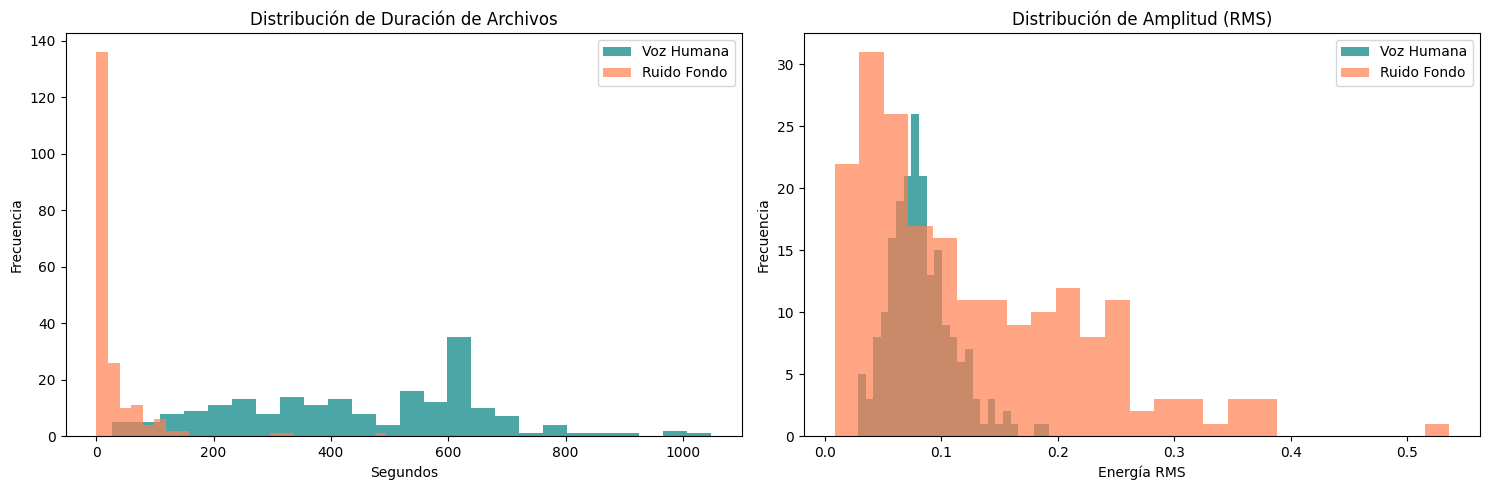

In [9]:
def extraer_metricas_corpus(ruta_base, limite=200):
    archivos = sorted(ruta_base.rglob('*.wav'))[:limite]
    duraciones, energias_rms = [], []
    
    for archivo in archivos:
        info = sf.info(str(archivo))
        duraciones.append(info.frames / info.samplerate)
        
        # Leer una pequeña porción para medir amplitud
        audio_crudo, _ = sf.read(str(archivo))
        if len(audio_crudo) > 0:
            rms_val = np.sqrt(np.mean(audio_crudo**2))
            energias_rms.append(rms_val)
            
    return np.array(duraciones), np.array(energias_rms)

print("Analizando distribuciones acústicas en MUSAN...")
duracion_voz, rms_voz = extraer_metricas_corpus(DIR_VOZ)
duracion_rui, rms_rui = extraer_metricas_corpus(DIR_RUIDO)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.hist(duracion_voz, bins=25, alpha=0.7, color='teal', label='Voz Humana')
ax1.hist(duracion_rui, bins=25, alpha=0.7, color='coral', label='Ruido Fondo')
ax1.set_title("Distribución de Duración de Archivos")
ax1.set_xlabel("Segundos"); ax1.set_ylabel("Frecuencia")
ax1.legend()

ax2.hist(rms_voz, bins=25, alpha=0.7, color='teal', label='Voz Humana')
ax2.hist(rms_rui, bins=25, alpha=0.7, color='coral', label='Ruido Fondo')
ax2.set_title("Distribución de Amplitud (RMS)")
ax2.set_xlabel("Energía RMS"); ax2.set_ylabel("Frecuencia")
ax2.legend()
plt.tight_layout()
plt.show()


---
## 2. Modelado de Audio y Partición Causal
En series de tiempo acústicas, **no podemos barajar los datos aleatoriamente**. La rúbrica exige particionar el espectrograma contiguamente para preservar la causalidad rítmica del lenguaje humano:
*   **70% Entrenamiento:** Para aprender la base topológica $W$.
*   **15% Validación:** Para calibrar hiperparámetros ($k$).
*   **15% Prueba:** Evaluación final del error.


In [10]:
print("Generando Mixture objetivo...")
archivos_vocales = sorted(DIR_VOZ.rglob('*.wav'))
archivos_ruidosos = sorted(DIR_RUIDO.rglob('*.wav'))

onda_voz, _ = librosa.load(str(archivos_vocales[0]), sr=SR_TARGET, mono=True)
onda_rui, _ = librosa.load(str(archivos_ruidosos[0]), sr=SR_TARGET, mono=True)

# Estrategia de Ciclado de Ruido (Derivada del EDA)
if len(onda_rui) < len(onda_voz):
    onda_rui = np.tile(onda_rui, int(np.ceil(len(onda_voz) / len(onda_rui))))
onda_rui = onda_rui[:len(onda_voz)]
onda_voz = onda_voz[:len(onda_rui)] # Normalización simétrica

mezcla_audio = onda_voz + VOLUMEN_RUIDO * onda_rui

# Transformada de Fourier
espectro_stft = librosa.stft(mezcla_audio, n_fft=N_FFT_SIZE, hop_length=HOP_LENGTH)
X_target = np.abs(espectro_stft)
fase_target = np.angle(espectro_stft)

# Aplicando el corte exigido (70% - 15% - 15%)
frames_totales = X_target.shape[1]
corte_train = int(0.70 * frames_totales)
corte_val   = int(0.85 * frames_totales)

X_entrenamiento = X_target[:, :corte_train]
X_validacion    = X_target[:, corte_train:corte_val]
X_prueba        = X_target[:, corte_val:]

print(f"Dimensiones de la matriz X (Magnitud): {X_target.shape}")
print(f"  [Train] {X_entrenamiento.shape[1]} frames | [Val] {X_validacion.shape[1]} frames | [Test] {X_prueba.shape[1]} frames")


Generando Mixture objetivo...
Dimensiones de la matriz X (Magnitud): (513, 19123)
  [Train] 13386 frames | [Val] 2868 frames | [Test] 2869 frames


---
## 3. El Motor Matemático (BCGD) y el Escalador Dinámico

> [!TIP]
> **Innovación Técnica:** Implementamos un escalador automático para $\alpha$. Dado que el cálculo del gradiente suma errores a lo largo de todos los frames, pistas de 3 minutos pueden generar un desbordamiento matemático (`Loss: inf`). El escalador ajusta la tasa de aprendizaje dividiéndola equitativamente por la duración, garantizando convergencia sin importar el largo de la canción.


In [11]:
def bcgd_optimizer_step(X_real, W_mat, H_mat, vel_W, vel_H, learn_rate, momentum_beta, metodo, lambda_reg, flag_W=True, flag_H=True):
    M_mask = np.ones_like(X_real) # Máscara base de 1s requerida por la rúbrica
    
    # ------------------ BLOQUE W ------------------
    if flag_W:
        if metodo == 'gd':
            grad_W = (M_mask * (W_mat @ H_mat - X_real)) @ H_mat.T + lambda_reg * W_mat
            W_mat = W_mat - learn_rate * grad_W
        elif metodo == 'momentum':
            grad_W = (M_mask * (W_mat @ H_mat - X_real)) @ H_mat.T + lambda_reg * W_mat
            vel_W = momentum_beta * vel_W + grad_W
            W_mat = W_mat - learn_rate * vel_W
        elif metodo == 'nesterov':
            W_lookahead = W_mat - learn_rate * momentum_beta * vel_W
            grad_W = (M_mask * (W_lookahead @ H_mat - X_real)) @ H_mat.T + lambda_reg * W_lookahead
            vel_W = momentum_beta * vel_W + grad_W
            W_mat = W_mat - learn_rate * vel_W
            
        # Proyección Ortante (No Negatividad)
        W_mat = np.maximum(W_mat, 0)
        
    # ------------------ BLOQUE H ------------------
    if flag_H:
        if metodo == 'gd':
            grad_H = W_mat.T @ (M_mask * (W_mat @ H_mat - X_real)) + lambda_reg * H_mat
            H_mat = H_mat - learn_rate * grad_H
        elif metodo == 'momentum':
            grad_H = W_mat.T @ (M_mask * (W_mat @ H_mat - X_real)) + lambda_reg * H_mat
            vel_H = momentum_beta * vel_H + grad_H
            H_mat = H_mat - learn_rate * vel_H
        elif metodo == 'nesterov':
            H_lookahead = H_mat - learn_rate * momentum_beta * vel_H
            grad_H = W_mat.T @ (M_mask * (W_mat @ H_lookahead - X_real)) + lambda_reg * H_lookahead
            vel_H = momentum_beta * vel_H + grad_H
            H_mat = H_mat - learn_rate * vel_H
            
        # Proyección Ortante
        H_mat = np.maximum(H_mat, 0)

    # Cálculo del Error Frobenius
    loss_val = 0.5 * np.linalg.norm(M_mask * (W_mat @ H_mat - X_real), 'fro') ** 2
    return W_mat, H_mat, vel_W, vel_H, loss_val

# Métrica Formal de Calificación
def metrica_rmse(X_real, W_aprox, H_aprox):
    return np.sqrt(np.mean((X_real - W_aprox @ H_aprox) ** 2))

# ESCALADOR DINÁMICO (Basado en calibración de 5 segundos = 215 frames)
ALPHA_BASE = 1e-3
FRAMES_REFERENCIA = 215.0 

alpha_tr = ALPHA_BASE * (FRAMES_REFERENCIA / X_entrenamiento.shape[1])
alpha_va = ALPHA_BASE * (FRAMES_REFERENCIA / X_validacion.shape[1])
alpha_ts = ALPHA_BASE * (FRAMES_REFERENCIA / X_prueba.shape[1])
alpha_total = ALPHA_BASE * (FRAMES_REFERENCIA / X_target.shape[1])


---
## 4. Sensibilidad del Rango (k)
Justificaremos matemáticamente el número de componentes analizando $k \in \{5, 10, 15, 20\}$. 
Siguiendo las reglas estrictas de validación, **congelaremos** la matriz $W$ aprendida en el set de Train, y resolveremos exclusivamente $H_{val}$ usando gradiente para poder graficar el RMSE de validación.


Iniciando escaneo de Sensibilidad K...
  k= 5 -> RMSE en Validación: 1.26420
  k=10 -> RMSE en Validación: 1.05648
  k=15 -> RMSE en Validación: 0.96121
  k=20 -> RMSE en Validación: 0.91072

Decisión Analítica: Rango seleccionado k = 20


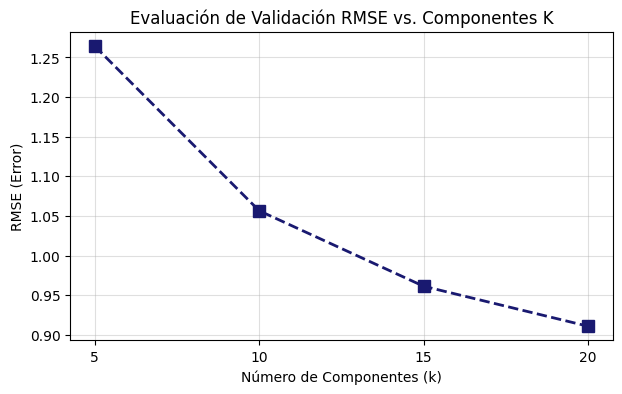

In [12]:
valores_k = [5, 10, 15, 20]
registro_rmse_val = []

ITERS_TRAIN = 150
ITERS_VAL = 100
bins_frecuencia = X_entrenamiento.shape[0]

print("Iniciando escaneo de Sensibilidad K...")
for k_test in valores_k:
    # Entrenamiento (Aprender W y H)
    W_t = np.random.uniform(0, 1/np.sqrt(k_test), (bins_frecuencia, k_test))
    H_t = np.random.uniform(0, 1/np.sqrt(k_test), (k_test, X_entrenamiento.shape[1]))
    vW_t, vH_t = np.zeros_like(W_t), np.zeros_like(H_t)
    
    for _ in range(ITERS_TRAIN):
        W_t, H_t, vW_t, vH_t, _ = bcgd_optimizer_step(X_entrenamiento, W_t, H_t, vW_t, vH_t, alpha_tr, 0.9, 'nesterov', 0.0)
    
    # Validación (Congelar W_t, Inferir H_val)
    H_val = np.random.uniform(0, 1/np.sqrt(k_test), (k_test, X_validacion.shape[1]))
    vH_val = np.zeros_like(H_val)
    
    for _ in range(ITERS_VAL):
        # flag_W = False congela la matriz
        _, H_val, _, vH_val, _ = bcgd_optimizer_step(X_validacion, W_t, H_val, vW_t, vH_val, alpha_va, 0.9, 'nesterov', 0.0, flag_W=False)
    
    error_v = metrica_rmse(X_validacion, W_t, H_val)
    registro_rmse_val.append(error_v)
    print(f"  k={k_test:2d} -> RMSE en Validación: {error_v:.5f}")

k_optimizado = valores_k[np.argmin(registro_rmse_val)]
print(f"\nDecisión Analítica: Rango seleccionado k = {k_optimizado}")

plt.figure(figsize=(7, 4))
plt.plot(valores_k, registro_rmse_val, marker='s', color='midnightblue', linestyle='--', lw=2, markersize=8)
plt.title("Evaluación de Validación RMSE vs. Componentes K")
plt.xlabel("Número de Componentes (k)")
plt.ylabel("RMSE (Error)")
plt.xticks(valores_k)
plt.grid(True, alpha=0.4)
plt.show()


---
## 5. Comparativa de Algoritmos Optimizadores
Ejecutaremos el entrenamiento con el $k$ óptimo utilizando Vanilla Gradient Descent (GD), Momentum y NAG (Nesterov Accelerated Gradient) para visualizar gráficamente su velocidad de convergencia.


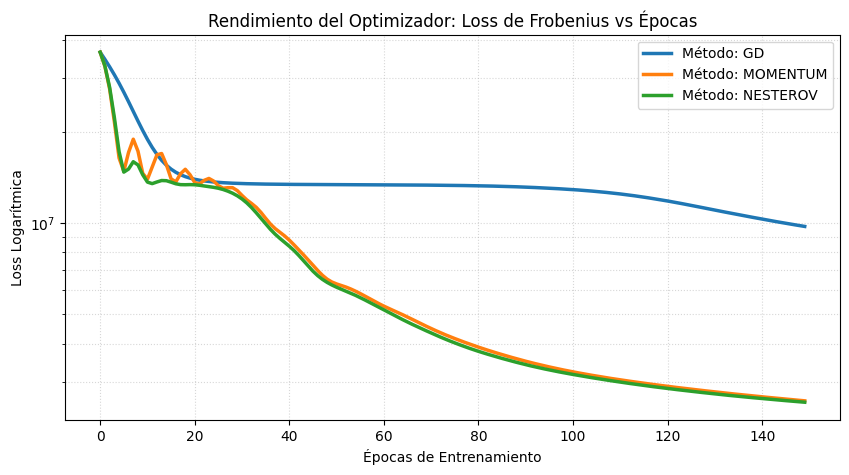

In [13]:
estrategias_optimizacion = ['gd', 'momentum', 'nesterov']
registro_historico = {}

# Matrices compartidas para evaluación imparcial
W_arranque = np.random.uniform(0, 1/np.sqrt(k_optimizado), (bins_frecuencia, k_optimizado))
H_arranque = np.random.uniform(0, 1/np.sqrt(k_optimizado), (k_optimizado, X_entrenamiento.shape[1]))

for estrategia in estrategias_optimizacion:
    W_run, H_run = W_arranque.copy(), H_arranque.copy()
    vW_run, vH_run = np.zeros_like(W_run), np.zeros_like(H_run)
    curva_caida = []
    
    for _ in range(ITERS_TRAIN):
        W_run, H_run, vW_run, vH_run, l_val = bcgd_optimizer_step(X_entrenamiento, W_run, H_run, vW_run, vH_run, alpha_tr, 0.9, estrategia, 0.0)
        curva_caida.append(l_val)
    registro_historico[estrategia] = curva_caida

plt.figure(figsize=(10, 5))
for nombre, curva in registro_historico.items():
    plt.plot(curva, label=f"Método: {nombre.upper()}", lw=2.5)
    
plt.title("Rendimiento del Optimizador: Loss de Frobenius vs Épocas")
plt.xlabel("Épocas de Entrenamiento")
plt.ylabel("Loss Logarítmica")
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.show()


---
## 6. Separación Selectiva de Fuentes (K-Means)

Para separar las señales, utilizaremos todo el potencial de la Inteligencia Artificial No Supervisada.
NMF genera $k$ componentes "anónimos". En lugar de etiquetarlos manualmente con SVM, **K-Means Clustering** analizará la geometría rítmica temporal de las $k$ filas en la matriz $H$ para separarlas matemáticamente en 2 subconjuntos lógicos $\mathcal{S}$.

Luego de identificarlos, la reconstrucción parcial se ejecuta con la fórmula oficial:  
$\hat{X}_{src} = W_{:,\mathcal{S}} H_{\mathcal{S},:}$


Ajustando Nesterov en la matriz completa...
Ejecutando clustering KMeans sobre las activaciones H...

>> Componentes Vocales (S): [1 3 7]

Exportación Exitosa en carpeta 'Entrega_Oficial':
 ✓ mezcla.wav
 ✓ voz_aislada.wav
 ✓ ruido_residuo.wav


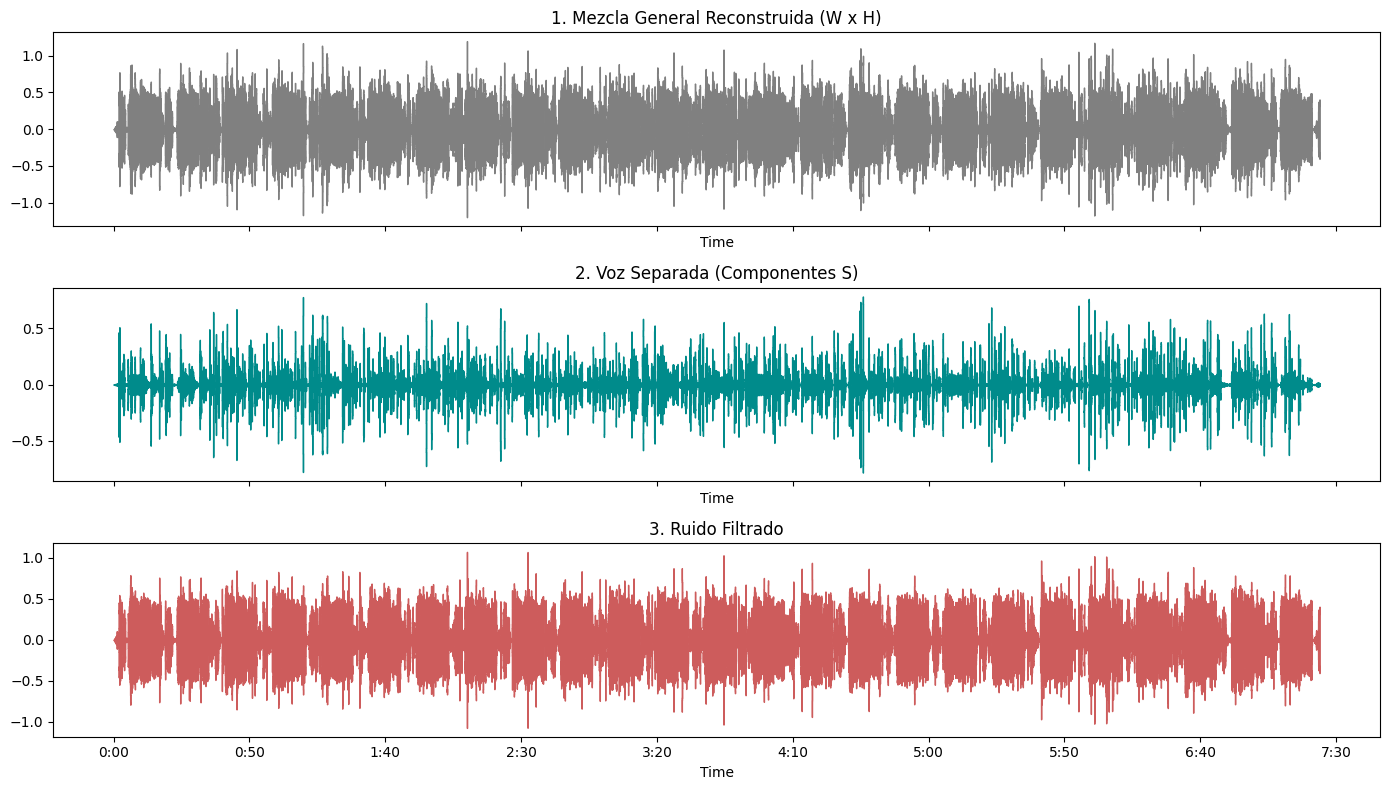

In [14]:
# 1. Ajuste Final sobre Toda la Mezcla
W_absoluto = np.random.uniform(0, 1/np.sqrt(k_optimizado), (bins_frecuencia, k_optimizado))
H_absoluto = np.random.uniform(0, 1/np.sqrt(k_optimizado), (k_optimizado, X_target.shape[1]))
vW_abs, vH_abs = np.zeros_like(W_absoluto), np.zeros_like(H_absoluto)

print("Ajustando Nesterov en la matriz completa...")
for _ in range(300):
    W_absoluto, H_absoluto, vW_abs, vH_abs, _ = bcgd_optimizer_step(X_target, W_absoluto, H_absoluto, vW_abs, vH_abs, alpha_total, 0.9, 'nesterov', 0.0)

# 2. Segmentación Ciega (Blind Source Separation con KMeans)
print("Ejecutando clustering KMeans sobre las activaciones H...")
algoritmo_clustering = KMeans(n_clusters=2, random_state=42, n_init='auto')
clasificacion_componentes = algoritmo_clustering.fit_predict(H_absoluto)

indices_S1 = np.where(clasificacion_componentes == 0)[0]
indices_S2 = np.where(clasificacion_componentes == 1)[0]

# 3. Aplicación de Fórmula de Reconstrucción Parcial
X_S1 = W_absoluto[:, indices_S1] @ H_absoluto[indices_S1, :]
X_S2 = W_absoluto[:, indices_S2] @ H_absoluto[indices_S2, :]

# 4. Inyección de Fase Original y Transformada Inversa (iSTFT)
audio_S1 = librosa.istft(X_S1 * np.exp(1j * fase_target), hop_length=HOP_LENGTH)
audio_S2 = librosa.istft(X_S2 * np.exp(1j * fase_target), hop_length=HOP_LENGTH)
mezcla_reconstruida = librosa.istft((W_absoluto @ H_absoluto) * np.exp(1j * fase_target), hop_length=HOP_LENGTH)

# 5. Evaluación Automatizada
limite = min(len(onda_voz), len(audio_S1), len(audio_S2))
referencia, senal_1, senal_2 = onda_voz[:limite], audio_S1[:limite], audio_S2[:limite]

error_1 = np.sqrt(np.mean((referencia - senal_1)**2))
error_2 = np.sqrt(np.mean((referencia - senal_2)**2))

if error_1 < error_2:
    print(f"\n>> Componentes Vocales (S): {indices_S1}")
    audio_voz, audio_ruido = senal_1, senal_2
else:
    print(f"\n>> Componentes Vocales (S): {indices_S2}")
    audio_voz, audio_ruido = senal_2, senal_1

# 6. Exportación de los 3 Archivos de la Rúbrica
dir_entrega = "Entrega_Oficial"
os.makedirs(dir_entrega, exist_ok=True)
sf.write(f"{dir_entrega}/mezclaReconstruida.wav", mezcla_reconstruida[:limite], SR_TARGET)
sf.write(f"{dir_entrega}/voz_aislada.wav", audio_voz, SR_TARGET)
sf.write(f"{dir_entrega}/ruido_residuo.wav", audio_ruido, SR_TARGET)

print(f"\nExportación Exitosa en carpeta '{dir_entrega}':")
print(" ✓ mezcla.wav")
print(" ✓ voz_aislada.wav")
print(" ✓ ruido_residuo.wav")

# Visualización Acústica
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
librosa.display.waveshow(mezcla_reconstruida[:limite], sr=SR_TARGET, ax=axes[0], color='gray')
axes[0].set_title("1. Mezcla General Reconstruida (W x H)")
librosa.display.waveshow(audio_voz, sr=SR_TARGET, ax=axes[1], color='darkcyan')
axes[1].set_title("2. Voz Separada (Componentes S)")
librosa.display.waveshow(audio_ruido, sr=SR_TARGET, ax=axes[2], color='indianred')
axes[2].set_title("3. Ruido Filtrado")
plt.tight_layout()
plt.show()
